In [1]:
import pandas as pd
import yfinance as yf
import datetime as dt

In [2]:
start=dt.datetime(2020,1,1)
end=dt.datetime(2023,12,31)
stk_data=yf.download("RELIANCE.NS",start="2020-1-1",end="2023-12-31")

[*********************100%***********************]  1 of 1 completed


In [3]:
stk_data.columns=stk_data.columns.get_level_values(0)

In [4]:
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [5]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data

Price,Open,High,Low,Close
Date,,,,
2020-01-01,675.956609,680.008790,670.390471,672.216125
2020-01-02,673.284861,686.176147,673.284861,683.660217
2020-01-03,682.636001,686.487835,678.183067,684.484009
2020-01-06,676.847260,680.365044,667.050769,668.609314
2020-01-07,676.402056,683.304159,673.952948,678.895752
...,...,...,...,...
2023-12-22,1264.550536,1275.073539,1258.646635,1267.243042
2023-12-26,1268.700501,1280.532788,1266.082053,1273.665649
2023-12-27,1275.617031,1284.460338,1271.220103,1278.013184


In [6]:
stk_data.to_csv("RELIANCE.NS.csv")

In [7]:
column="Close"

In [8]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
data1=ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (992, 1)


In [9]:
len(data1)

992

In [10]:
orders=[(1,0,2),(1,0,1),(2,0,1),(1,0,1)]
for i in orders:
    from statsmodels.tsa.arima.model import ARIMA
    model=ARIMA(data1,order=i)
    model_fit=model.fit()

    y_pred=model_fit.predict(0,len(data1)-1)
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)

RMSE-Testset: 0.02240962848491396
MAPE-Testset: 320644109437.35455
RMSE-Testset: 0.022441220319707335
MAPE-Testset: 321569653552.64594
RMSE-Testset: 0.02244926146151016
MAPE-Testset: 316939424336.4035
RMSE-Testset: 0.022441220319707335
MAPE-Testset: 321569653552.64594


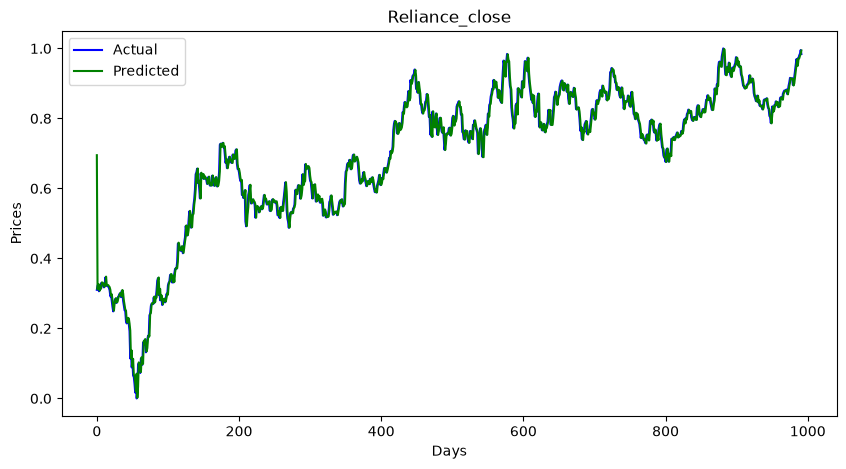

In [11]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","Reliance_close","Days","Prices")

In [12]:
from stockFunctions import conversionSingle
atestnormtable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=ms.inverse_transform(atestnormtable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["close"])

In [13]:
actual_stock_price_test_oriA

,close
0,672.216125
1,683.660217
2,684.484009
3,668.609314
4,678.895752
...,...
987,1267.243042
988,1273.665649
989,1278.013184
990,1287.251831


In [14]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

In [15]:
predicted_stock_price_test_oriP

,Close
0,1017.525769
1,673.898086
2,685.616464
3,686.159583
4,669.949277
...,...
987,1265.21976
988,1266.016495
989,1272.549077
990,1276.818884


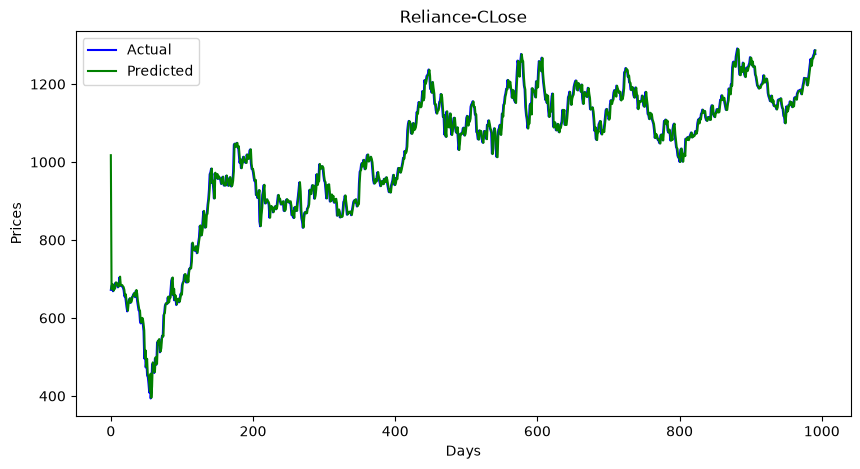

In [16]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","Reliance-CLose","Days","Prices")

In [17]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 20.144629060027427
MAPE-Testset: 0.013588465256240573


In [18]:
forecast=model_fit.predict(len(data1),len(data1)+5)

In [19]:
forecast

array([0.98238959, 0.98091882, 0.97945558, 0.97799982, 0.97655151,
       0.97511062])

In [20]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [21]:
forecast_stock_price_test_oriF

,Closefore
0,1275.516149
1,1274.195894
2,1272.882395
3,1271.575618
4,1270.275528
5,1268.982092


In [22]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)